# Spatial Analysis & Geospatial Heatmaps
Comprehensive spatial visualization and analysis of India's crime, mining, court, and household data

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load and Prepare Spatial Data

In [ ]:
gdf_states = gpd.read_file('data/geo/india_states.geojson')
gdf_districts = gpd.read_file('india_districts_simple.geojson')

crime_data = pd.read_csv('data/crime/crime_in_india_github.csv')
household_data = pd.read_csv('data/household.csv')
mining_data = pd.read_csv('data/indiasandwatch/mining_obs.csv', header=0)  # Fixed: use header=0
court_data = pd.read_csv('data/indiasandwatch/court_docs.csv')
news_data = pd.read_csv('data/indiasandwatch/news_reports.csv')
mining_news = pd.read_csv('data/indiasandwatch/mining_news_reporrts.csv')
district_surveys = pd.read_csv('data/indiasandwatch/district_survey_reports.csv')

print("Data loaded successfully!")
print(f"Crime data shape: {crime_data.shape}")
print(f"Household data shape: {household_data.shape}")
print(f"Mining observations shape: {mining_data.shape}")
print(f"Court data shape: {court_data.shape}")
print(f"States GeoDataFrame: {gdf_states.shape}")
print(f"Districts GeoDataFrame: {gdf_districts.shape}")

Data loaded successfully!
Crime data shape: (4916, 8)
Household data shape: (216, 5)
Mining observations shape: (375, 12)
Court data shape: (91, 28)
States GeoDataFrame: (36, 6)
Districts GeoDataFrame: (594, 12)


In [ ]:
print("Crime data columns:", crime_data.columns.tolist())
print("\nHousehold data columns:", household_data.columns.tolist())
print("\nMining data columns:", mining_data.columns.tolist())
print("\nCourt data columns:", court_data.columns.tolist())
print("\nStates GeoDataFrame columns:", gdf_states.columns.tolist())

Crime data columns: ['city', 'crime_name', '2010', '2011', '2012', '2013', '2014', 'avg']

Household data columns: ['Country', 'State', 'Year', 'Condition Of House', 'Percentage Of Households (UOM:%(Percentage)), Scaling Factor:1']

Mining data columns: ['Tribeni - Hooghly / Bhagirathi River, 2016', 'N/A', '17-06-2016 18:30:00', 'Serial Number,Latitude,Longitude\n1,22.973344,88.405614\n', 'Yes', 'Pumps loaded on to boats were being used. ', 'Possibly bottom dredgers which then transport the extracted material via pipes to the riverbank', 'https://storage.googleapis.com/download/storage/v1/b/ved_prod__media/o/images%2Fimg_20160617_103012_56a865c7-7bdf-4f1c-9275-16b84ba22303.jpeg?generation=1687766819526489&alt=media', 'West Bengal', 'Murshidabad', 'Ganga', '26-06-2023']

Court data columns: ['Title', 'Link to the case on court sites / other sites', 'PDF', 'Type of Document', 'Summary', 'Start Date/ Registration date/ original application date of the case (as applicable)', 'Application n

## 3. Prepare Data for Spatial Analysis

In [ ]:
# Aggregate crime data by city
numeric_cols = ['2010', '2011', '2012', '2013', '2014']
crime_data_numeric = crime_data.copy()
for col in numeric_cols:
    crime_data_numeric[col] = pd.to_numeric(crime_data_numeric[col], errors='coerce')

crime_by_city = crime_data_numeric.groupby('city')[numeric_cols].sum()
crime_by_city['total_crimes'] = crime_by_city.sum(axis=1)
crime_by_city = crime_by_city.sort_values('total_crimes', ascending=False)

# Aggregate household data by state
household_by_state = household_data.groupby('State').apply(
    lambda x: pd.Series({
        'Good': (x[x['Condition Of House'] == 'Good']['Percentage Of Households (UOM:%(Percentage)), Scaling Factor:1'].astype(float).mean()),
        'Liveable': (x[x['Condition Of House'] == 'Liveable']['Percentage Of Households (UOM:%(Percentage)), Scaling Factor:1'].astype(float).mean()),
        'Dilapidated': (x[x['Condition Of House'] == 'Dilapidated']['Percentage Of Households (UOM:%(Percentage)), Scaling Factor:1'].astype(float).mean()),
    })
).fillna(0)

# Aggregate mining data by state (clean the State column)
mining_data_clean = mining_data.dropna(subset=['State'])
mining_by_state = mining_data_clean.groupby('State').size().reset_index(name='total_observations')
mining_by_state = mining_by_state[mining_by_state['State'] != ''].sort_values('total_observations', ascending=False)

# Aggregate court data by state/district
court_by_state = court_data.dropna(subset=['State']).groupby('State').size().reset_index(name='total_cases') if 'State' in court_data.columns else pd.DataFrame()

print("✓ Data aggregated by geographic regions")
print(f"Top 10 cities by crime rate:\n{crime_by_city.head(10)[['total_crimes']]}")
print(f"\nHousehold conditions by state (sample):\n{household_by_state.head()}")

✓ Data aggregated by geographic regions
Top 10 cities by crime rate:
            total_crimes
city                    
Kochi            11860.1
Indore            9623.0
Jaipur            8726.5
Bhopal            8039.4
Gwalior           7226.3
Patna             7127.3
Vijayawada        7092.4
Jabalpur          6591.1
Delhi             6247.8
Kollam            6124.1

Household conditions by state (sample):
                               Good  Liveable  Dilapidated
State                                                     
Andaman and Nicobar Islands  69.300    28.615        2.085
Andhra Pradesh               75.435    22.720        1.845
Arunachal Pradesh            57.415    38.895        3.695
Assam                        55.450    38.455        6.095
Bihar                        53.635    38.895        7.470


## 4. Create Heatmaps for Data Intensity

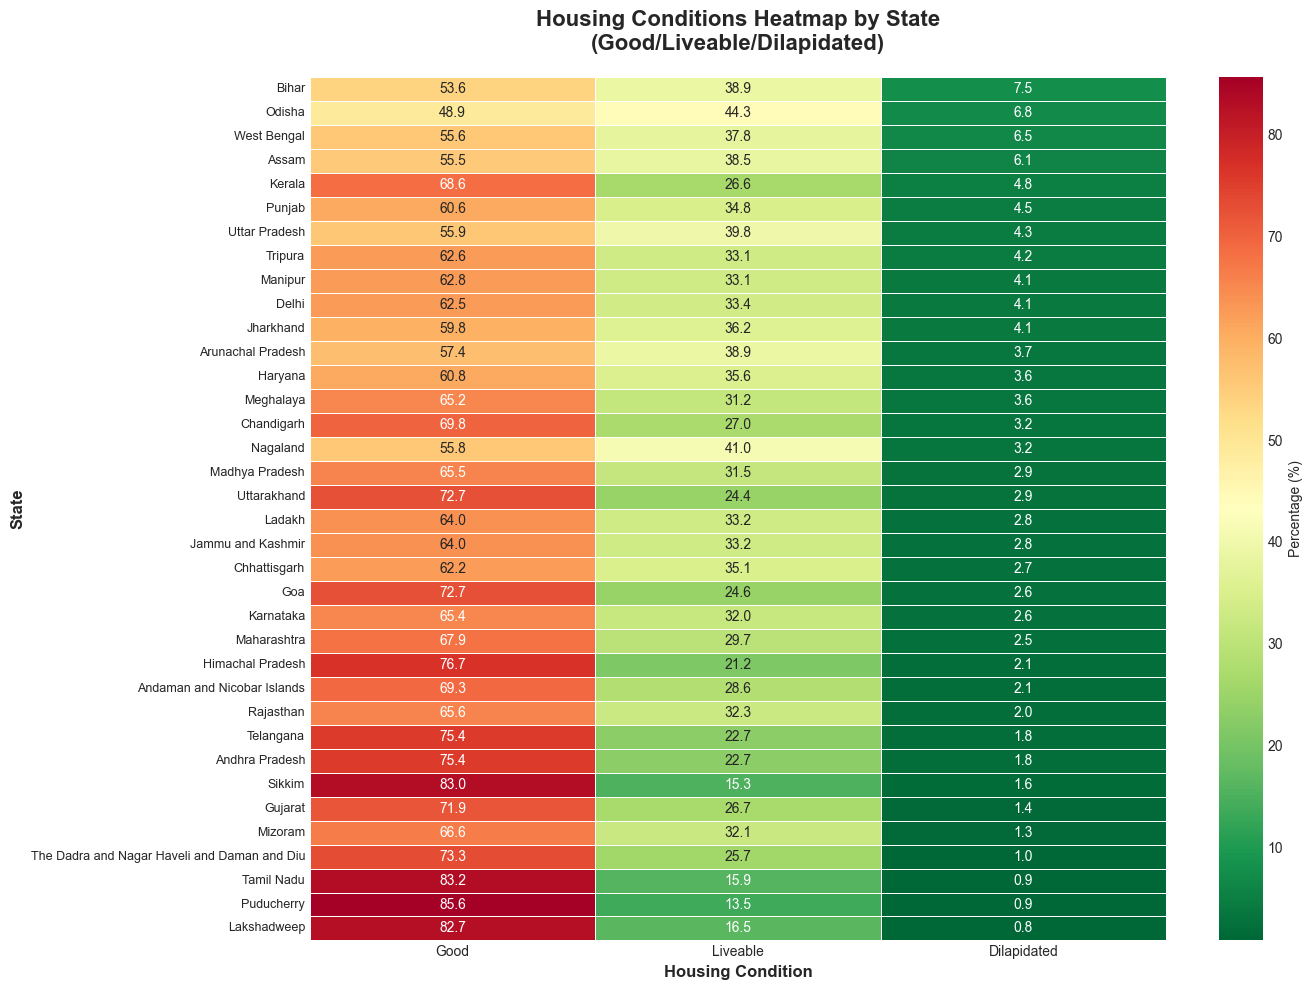

In [28]:
import os
os.makedirs('outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 10))
household_by_state_sorted = household_by_state.sort_values('Dilapidated', ascending=False)
sns.heatmap(household_by_state_sorted, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)
ax.set_title('Housing Conditions Heatmap by State\n(Good/Liveable/Dilapidated)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('State', fontsize=12, fontweight='bold')
ax.set_xlabel('Housing Condition', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/heatmap_household_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

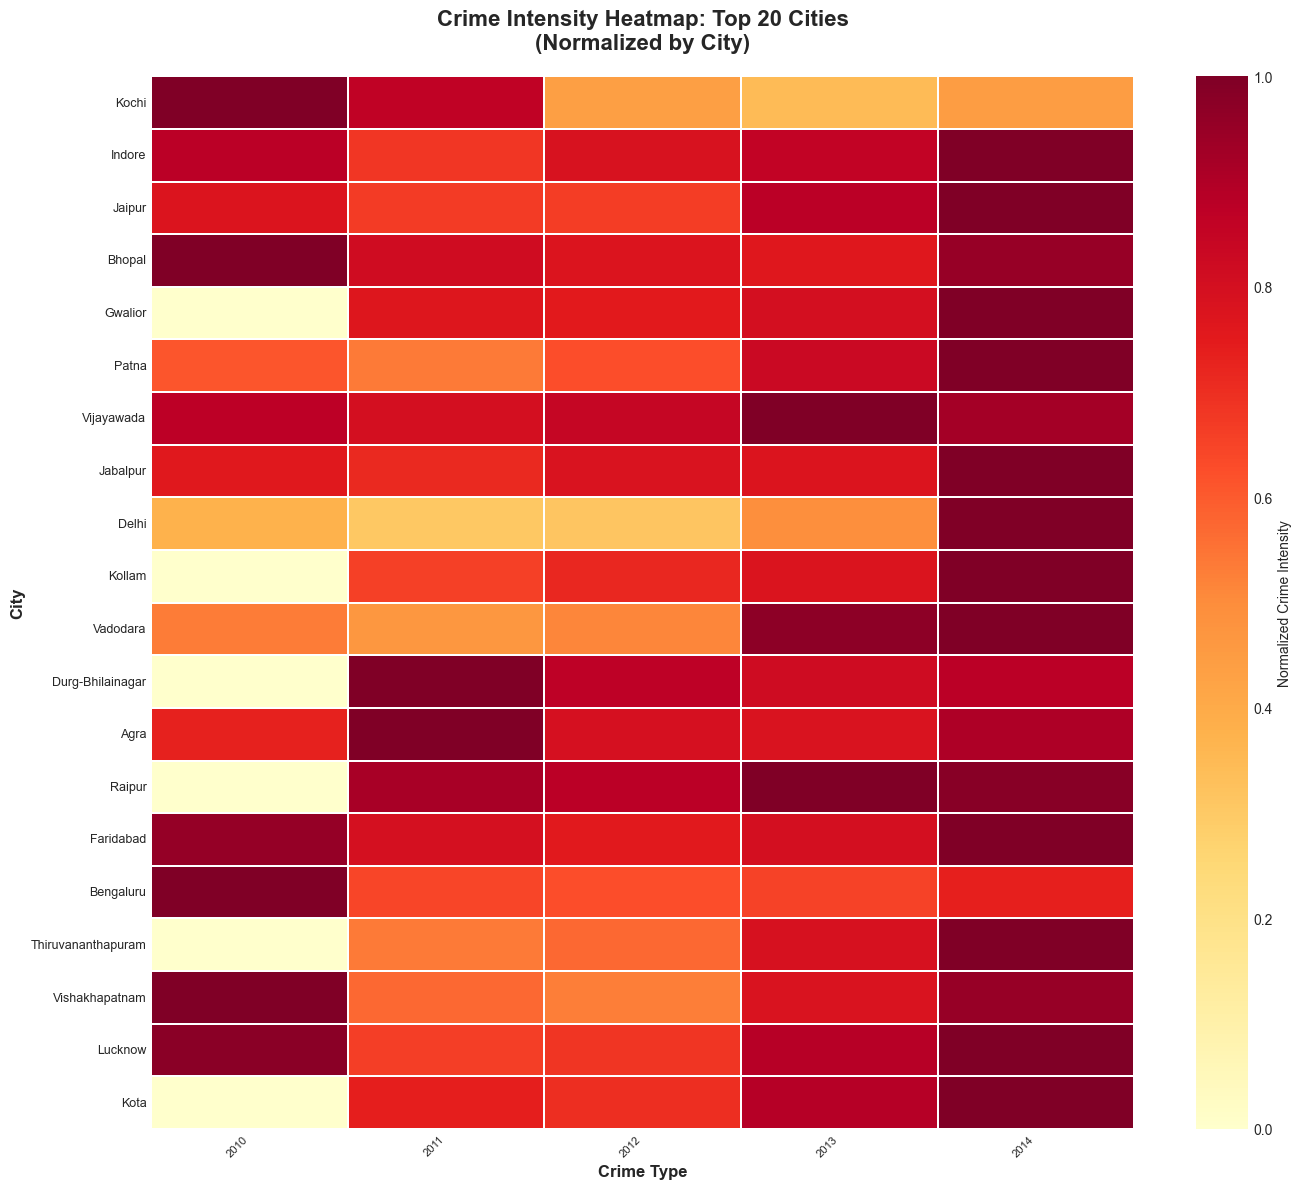

In [29]:
fig, ax = plt.subplots(figsize=(14, 12))
top_20_cities = crime_by_city.head(20).drop('total_crimes', axis=1)
top_20_cities_norm = top_20_cities.div(top_20_cities.max(axis=1), axis=0)
sns.heatmap(top_20_cities_norm, annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'Normalized Crime Intensity'}, ax=ax, linewidths=0.3)
ax.set_title('Crime Intensity Heatmap: Top 20 Cities\n(Normalized by City)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('City', fontsize=12, fontweight='bold')
ax.set_xlabel('Crime Type', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/heatmap_crime_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

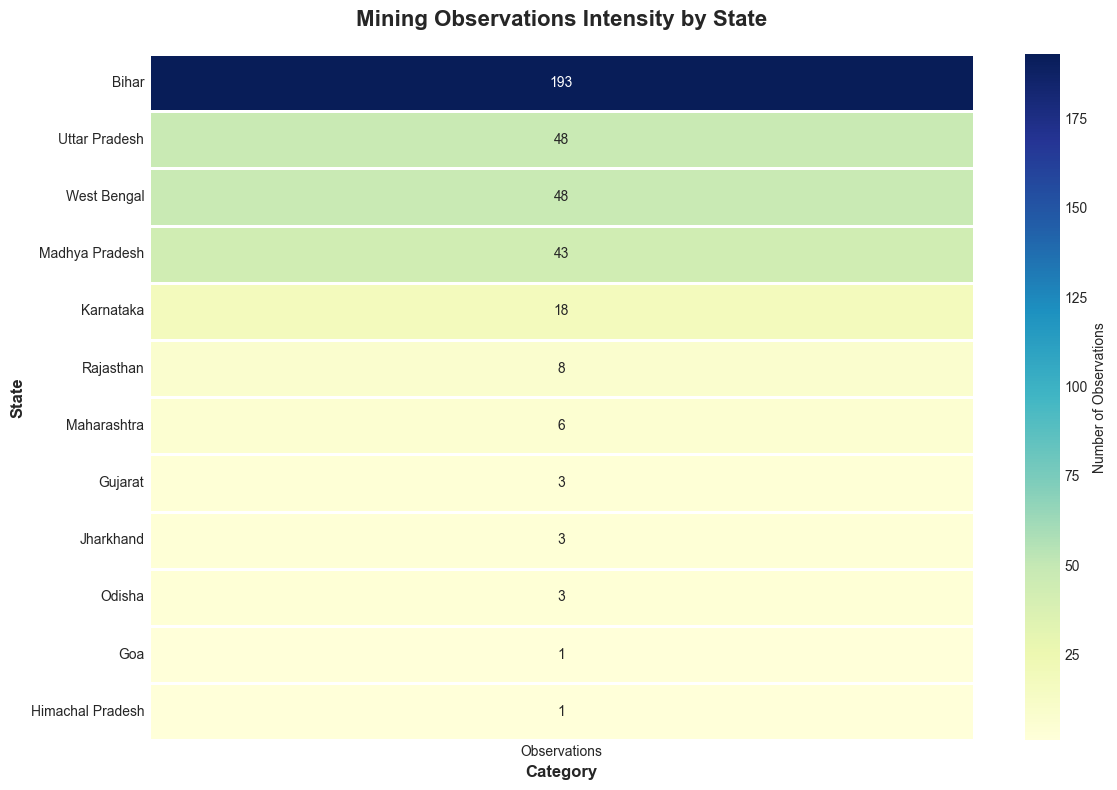

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))
mining_pivot = mining_by_state.set_index('State')['total_observations'].sort_values(ascending=False)
mining_2d = pd.DataFrame({
    'Observations': mining_pivot.values
}, index=mining_pivot.index)

sns.heatmap(mining_2d, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Number of Observations'}, ax=ax, linewidths=1)
ax.set_title('Mining Observations Intensity by State', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('State', fontsize=12, fontweight='bold')
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('outputs/heatmap_mining_observations.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Generate Interactive Choropleth Maps with Folium

In [31]:
mining_json = json.loads(gdf_states.to_json())

mining_map_data = mining_by_state[['State', 'total_observations']].copy()
mining_map_data.columns = ['NAME_1', 'total_observations']

m_mining = folium.Map(
    location=[20.5937, 78.9629],  # Center of India
    zoom_start=5,
    tiles='OpenStreetMap'
)

try:
    folium.Choropleth(
        geo_data=mining_json,
        name='Mining Observations',
        data=mining_map_data,
        columns=['NAME_1', 'total_observations'],
        key_on='feature.properties.NAME_1',
        fill_color='YlGn',
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name='Number of Mining Observations',
        nan_fill_color='white'
    ).add_to(m_mining)
except Exception as e:
    print(f"Warning: Choropleth mapping had issues: {e}")
    print("Creating base map...")

folium.LayerControl().add_to(m_mining)
m_mining.save('outputs/choropleth_mining_observations.html')

print("Saved to choropleth_mining_observations.html")

Saved to choropleth_mining_observations.html


In [32]:
m_housing = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles='OpenStreetMap'
)

housing_dilapidated = household_by_state[['Dilapidated']].copy()
housing_dilapidated['NAME_1'] = housing_dilapidated.index

housing_json = json.loads(gdf_states.to_json())

try:
    folium.Choropleth(
        geo_data=housing_json,
        name='Dilapidated Houses %',
        data=housing_dilapidated,
        columns=['NAME_1', 'Dilapidated'],
        key_on='feature.properties.NAME_1',
        fill_color='Reds',
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name='Percentage of Dilapidated Houses',
        nan_fill_color='white'
    ).add_to(m_housing)
except Exception as e:
    print(f"Warning: {e}")

folium.LayerControl().add_to(m_housing)
m_housing.save('outputs/choropleth_housing_dilapidated.html')

print("Saved to choropleth_housing_dilapidated.html")

Saved to choropleth_housing_dilapidated.html


## 6. Geographic Distribution Visualizations

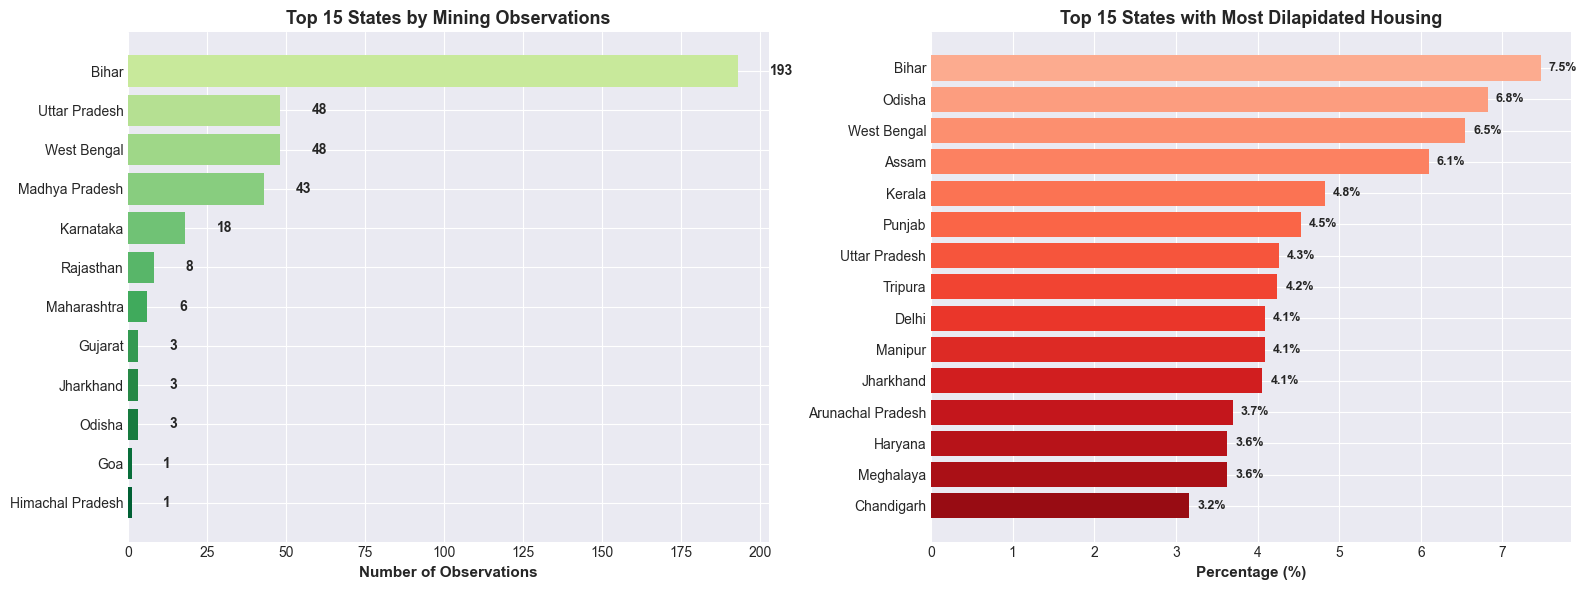

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_mining_states = mining_by_state.nlargest(15, 'total_observations')
colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(top_mining_states)))
ax1.barh(range(len(top_mining_states)), top_mining_states['total_observations'], color=colors)
ax1.set_yticks(range(len(top_mining_states)))
ax1.set_yticklabels(top_mining_states['State'])
ax1.set_xlabel('Number of Observations', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 States by Mining Observations', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_mining_states['total_observations']):
    ax1.text(v + 10, i, str(int(v)), va='center', fontweight='bold')

top_dilapidated = household_by_state['Dilapidated'].nlargest(15)
colors2 = plt.cm.Reds(np.linspace(0.3, 0.9, len(top_dilapidated)))
ax2.barh(range(len(top_dilapidated)), top_dilapidated.values, color=colors2)
ax2.set_yticks(range(len(top_dilapidated)))
ax2.set_yticklabels(top_dilapidated.index)
ax2.set_xlabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_title('Top 15 States with Most Dilapidated Housing', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(top_dilapidated.values):
    ax2.text(v + 0.1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/geographic_distribution_bars.png', dpi=300, bbox_inches='tight')
plt.show()

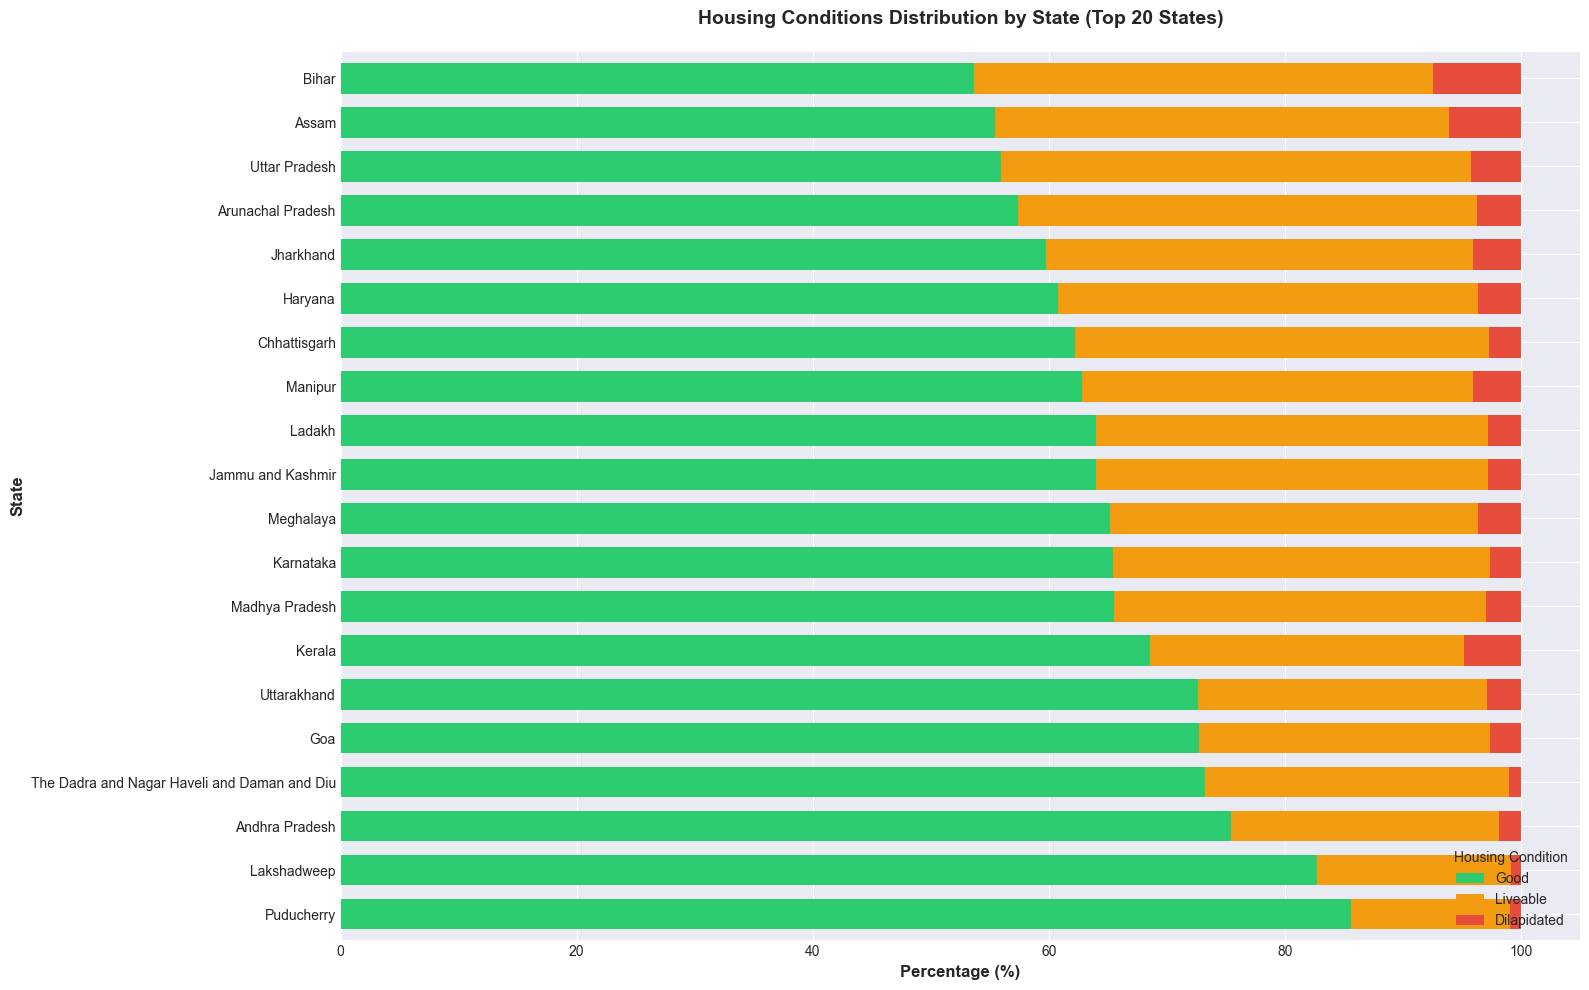

In [34]:
fig, ax = plt.subplots(figsize=(16, 10))

top_states_housing = household_by_state.sum(axis=1).nlargest(20).index
household_top = household_by_state.loc[top_states_housing].sort_values('Good', ascending=False)

household_top.plot(kind='barh', stacked=True, ax=ax, 
                   color=['#2ecc71', '#f39c12', '#e74c3c'],
                   width=0.7)
ax.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('State', fontsize=12, fontweight='bold')
ax.set_title('Housing Conditions Distribution by State (Top 20 States)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Housing Condition', loc='lower right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/housing_stacked_bars.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Advanced: Correlation Heatmaps and Multi-Dimensional Analysis

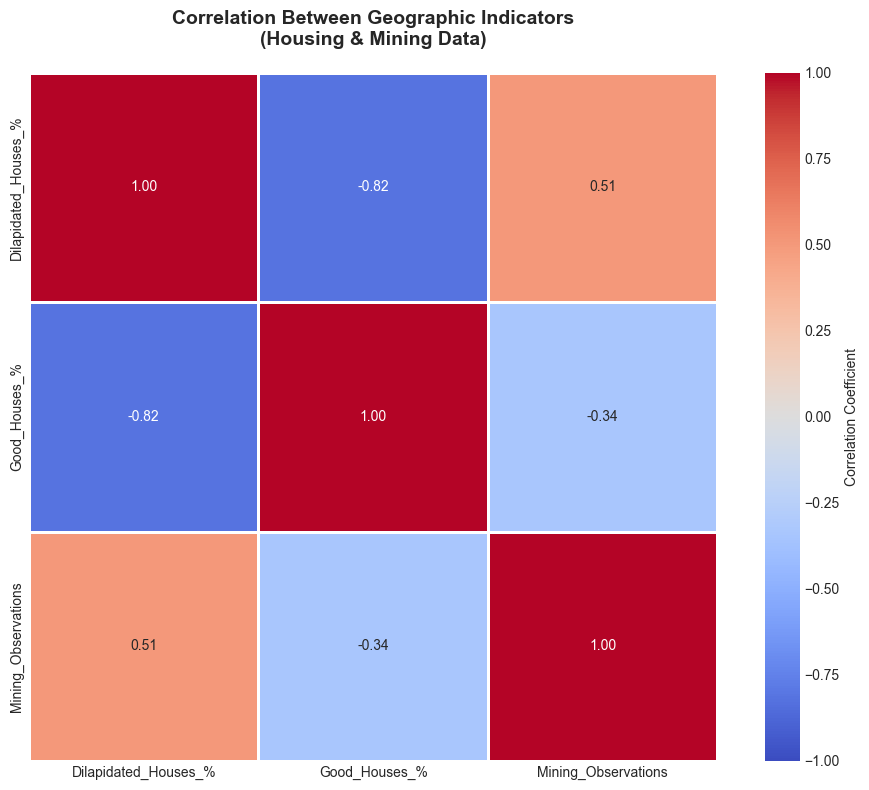


Correlation Matrix:
                      Dilapidated_Houses_%  Good_Houses_%  Mining_Observations
Dilapidated_Houses_%              1.000000      -0.818261             0.507405
Good_Houses_%                    -0.818261       1.000000            -0.342482
Mining_Observations               0.507405      -0.342482             1.000000


In [36]:
state_analysis = pd.DataFrame(index=household_by_state.index)

state_analysis['Dilapidated_Houses_%'] = household_by_state['Dilapidated']
state_analysis['Good_Houses_%'] = household_by_state['Good']

mining_dict = dict(zip(mining_by_state['State'], mining_by_state['total_observations']))
state_analysis['Mining_Observations'] = state_analysis.index.map(mining_dict).fillna(0)

state_analysis_norm = (state_analysis - state_analysis.mean()) / state_analysis.std()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = state_analysis.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Between Geographic Indicators\n(Housing & Mining Data)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)

## 8. Summary Report and Key Insights

In [38]:
print("\n DATASET OVERVIEW:")
print(f"  • Total Crime Records: {len(crime_data):,}")
print(f"  • Crime Types: {len(crime_data['crime_name'].unique())}")
print(f"  • Cities Analyzed: {len(crime_data['city'].unique())}")
print(f"  • Total Household Records: {len(household_data):,}")
print(f"  • Mining Observations: {len(mining_data):,}")
print(f"  • Court Documents: {len(court_data):,}")
print(f"  • News Reports: {len(news_data):,}")

print("\nTOP CRIME HOTSPOTS:")
top_5_crime = crime_by_city.head(5)
for idx, (city, row) in enumerate(top_5_crime.iterrows(), 1):
    print(f"  {idx}. {city}: {row['total_crimes']:.0f} total incidents")

print("\nHOUSING CRISIS HOTSPOTS (Dilapidated Houses):")
top_5_dilapidated = household_by_state['Dilapidated'].nlargest(5)
for idx, (state, pct) in enumerate(top_5_dilapidated.items(), 1):
    print(f"  {idx}. {state}: {pct:.1f}%")

print("\nTOP MINING ACTIVITY REGIONS:")
top_5_mining = mining_by_state.nlargest(5, 'total_observations')
for idx, row in top_5_mining.iterrows():
    print(f"  {idx+1}. {row['State']}: {int(row['total_observations'])} observations")

print("\nSPATIAL CORRELATION INSIGHTS:")
if len(corr_matrix) > 1:
    print(f"  • Correlation between Dilapidated Houses & Mining Activity: {corr_matrix.loc['Dilapidated_Houses_%', 'Mining_Observations']:.3f}")
    print(f"  • Correlation between Good Houses & Dilapidated Houses: {corr_matrix.loc['Good_Houses_%', 'Dilapidated_Houses_%']:.3f}")

print("\n\nOUTPUTS GENERATED:")
import os
output_files = os.listdir('outputs')
for i, file in enumerate(sorted(output_files), 1):
    print(f"  {i}. {file}")


 DATASET OVERVIEW:
  • Total Crime Records: 4,916
  • Crime Types: 94
  • Cities Analyzed: 54
  • Total Household Records: 216
  • Mining Observations: 375
  • Court Documents: 91
  • News Reports: 124

TOP CRIME HOTSPOTS:
  1. Kochi: 11860 total incidents
  2. Indore: 9623 total incidents
  3. Jaipur: 8726 total incidents
  4. Bhopal: 8039 total incidents
  5. Gwalior: 7226 total incidents

HOUSING CRISIS HOTSPOTS (Dilapidated Houses):
  1. Bihar: 7.5%
  2. Odisha: 6.8%
  3. West Bengal: 6.5%
  4. Assam: 6.1%
  5. Kerala: 4.8%

TOP MINING ACTIVITY REGIONS:
  1. Bihar: 193 observations
  11. Uttar Pradesh: 48 observations
  12. West Bengal: 48 observations
  7. Madhya Pradesh: 43 observations
  6. Karnataka: 18 observations

SPATIAL CORRELATION INSIGHTS:
  • Correlation between Dilapidated Houses & Mining Activity: 0.507
  • Correlation between Good Houses & Dilapidated Houses: -0.818


OUTPUTS GENERATED:
  1. choropleth_housing_dilapidated.html
  2. choropleth_mining_observations.htm

## 9. Export Results and Data

In [39]:
crime_by_city.to_csv('outputs/crime_by_city_analysis.csv')
household_by_state.to_csv('outputs/household_by_state_analysis.csv')
mining_by_state.to_csv('outputs/mining_by_state_analysis.csv')
state_analysis.to_csv('outputs/comprehensive_state_indicators.csv')

with open('outputs/spatial_analysis_summary.txt', 'w') as f:
    f.write("SPATIAL ANALYSIS SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(f"Generated: {pd.Timestamp.now()}\n\n")
    
    f.write("DATASET STATISTICS:\n")
    f.write(f"  Crime Records: {len(crime_data):,} across {len(crime_data['city'].unique())} cities\n")
    f.write(f"  Household Data: {len(household_data):,} records\n")
    f.write(f"  Mining Observations: {len(mining_data):,}\n")
    f.write(f"  Court Documents: {len(court_data):,}\n")
    f.write(f"  States/Territories Analyzed: {len(household_by_state)}\n\n")
    
    f.write("TOP CRIME HOTSPOTS:\n")
    for city, row in crime_by_city.head(10).iterrows():
        f.write(f"  {city}: {row['total_crimes']:.0f}\n")
    
    f.write("\nMINING ACTIVITY HOTSPOTS:\n")
    for _, row in mining_by_state.nlargest(10, 'total_observations').iterrows():
        f.write(f"  {row['State']}: {int(row['total_observations'])}\n")

print("Data exported successfully!")
print("   • crime_by_city_analysis.csv")
print("   • household_by_state_analysis.csv")
print("   • mining_by_state_analysis.csv")
print("   • comprehensive_state_indicators.csv")
print("   • spatial_analysis_summary.txt")

print("\nVISUALIZATIONS CREATED:")
viz_files = [f for f in os.listdir('outputs') if f.endswith(('.png', '.html'))]
for file in sorted(viz_files):
    print(f"   • {file}")

Data exported successfully!
   • crime_by_city_analysis.csv
   • household_by_state_analysis.csv
   • mining_by_state_analysis.csv
   • comprehensive_state_indicators.csv
   • spatial_analysis_summary.txt

VISUALIZATIONS CREATED:
   • choropleth_housing_dilapidated.html
   • choropleth_mining_observations.html
   • correlation_heatmap_indicators.png
   • geographic_distribution_bars.png
   • heatmap_crime_intensity.png
   • heatmap_household_conditions.png
   • heatmap_mining_observations.png
   • housing_stacked_bars.png
